In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [9]:
import pandas as pd

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/world_happiness_ml.csv")

df_ml.head()

,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,Education_Index,Population,Urbanization_Rate,Life_Satisfaction,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate,Year_bin
0,China,2022,4.39,44984.68,0.53,71.11,0.41,-0.05,0.83,14.98,0.52,1311940760,78.71,8.88,0.34,76.44,46.06,8.92,62.75,8.59,74.40,70.30,0.29,61.38,2020
1,UK,2015,5.49,30814.59,0.93,63.14,0.89,0.04,0.84,19.46,0.83,1194240877,50.87,5.03,0.72,53.38,46.43,4.43,53.11,8.76,91.74,73.32,0.76,80.18,2015
2,Brazil,2009,4.65,39214.84,0.03,62.36,0.01,0.16,0.59,16.68,0.95,731100898,48.75,5.22,0.23,82.40,31.03,3.78,33.30,6.06,71.80,28.99,0.94,72.65,2005
3,France,2019,5.20,30655.75,0.77,78.94,0.98,0.25,0.63,2.64,0.70,1293957314,81.78,5.69,0.68,46.87,57.65,4.43,90.59,6.36,86.16,45.76,0.48,55.14,2015
4,China,2022,7.28,30016.87,0.05,50.33,0.62,0.18,0.92,7.70,0.92,1432971455,82.39,6.33,0.50,60.38,28.54,7.66,59.33,3.00,71.10,65.67,0.12,51.55,2020


In [10]:
# Target variable
y = df_ml["Life_Satisfaction"]

# Features
X = df_ml.drop(columns=["Life_Satisfaction", "Country", "Year_bin"])
# One-hot encode Country
# X = pd.get_dummies(X, columns=["Country"], drop_first=True)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train, y_train)

y_pred_lin = linreg.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression Results")
print("MAE:", mae_lin)
print("RMSE:", rmse_lin)
print("R2:", r2_lin)

Linear Regression Results
MAE: 1.212413268604085
RMSE: 1.4151853497045146
R2: -0.0021249476812303936


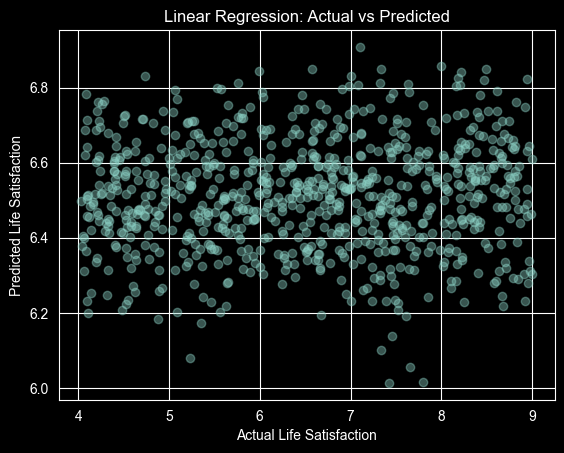

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lin, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [15]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Results")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

Decision Tree Regressor Results
MAE: 1.2625149659878074
RMSE: 1.4989837150680796
R2: -0.12431771953496318


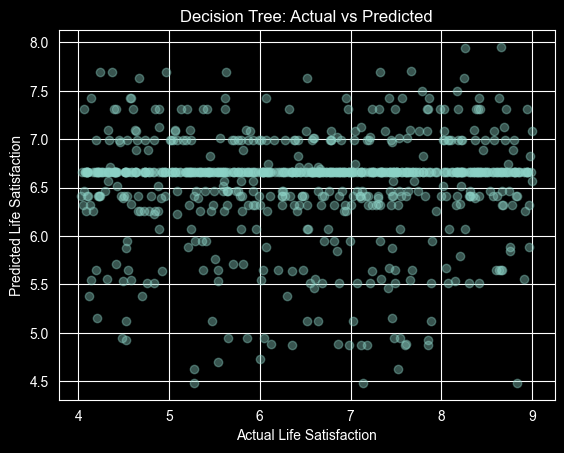

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_tree, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

In [18]:
import pandas as pd

tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

tree_importance.head(15)

Climate_Index                0.111430
Corruption_Perception        0.081507
Mental_Health_Index          0.081334
Generosity                   0.074296
Political_Stability          0.057642
Public_Health_Expenditure    0.056324
Population                   0.055839
Happiness_Score              0.050461
Internet_Access              0.045591
Social_Support               0.045496
Unemployment_Rate            0.045270
Employment_Rate              0.038974
Healthy_Life_Expectancy      0.038304
Income_Inequality            0.037019
Crime_Rate                   0.034543
dtype: float64

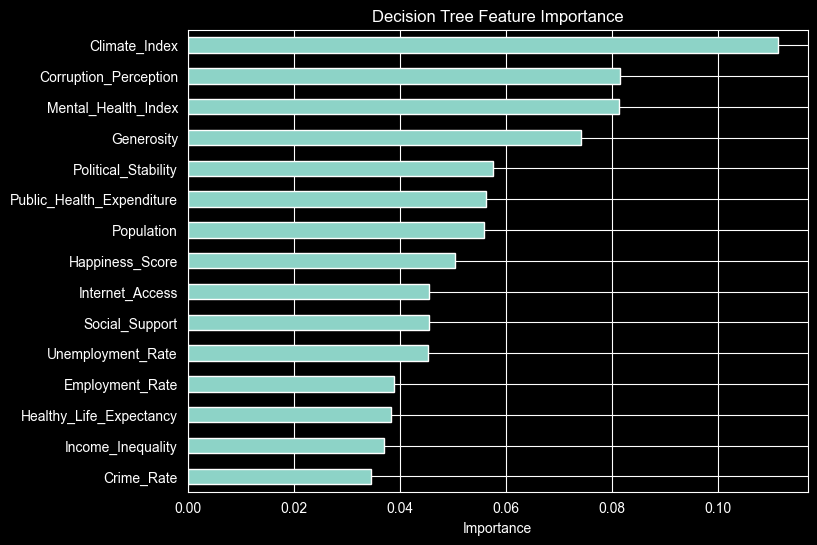

In [19]:
tree_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    max_features="sqrt",
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Regressor Results
MAE: 1.2152253794084846
RMSE: 1.4185101364642656
R2: -0.0068391932408189415


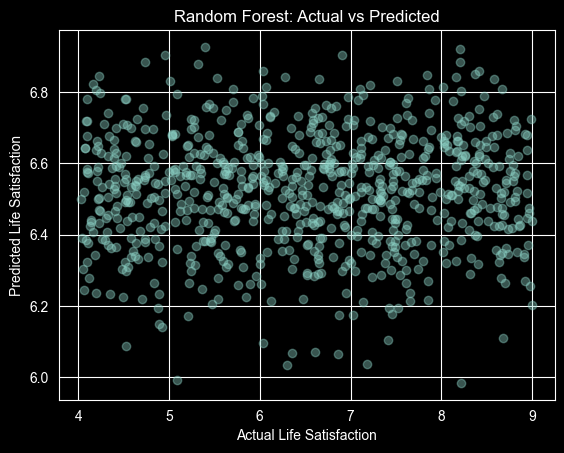

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [23]:
import pandas as pd

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(15)

Income_Inequality            0.055259
GDP_per_Capita               0.051125
Population                   0.050930
Employment_Rate              0.048716
Urbanization_Rate            0.047941
Mental_Health_Index          0.047935
Happiness_Score              0.047713
Internet_Access              0.046886
Crime_Rate                   0.046567
Climate_Index                0.046450
Work_Life_Balance            0.046324
Healthy_Life_Expectancy      0.046266
Unemployment_Rate            0.045024
Public_Health_Expenditure    0.044929
Freedom                      0.044715
dtype: float64

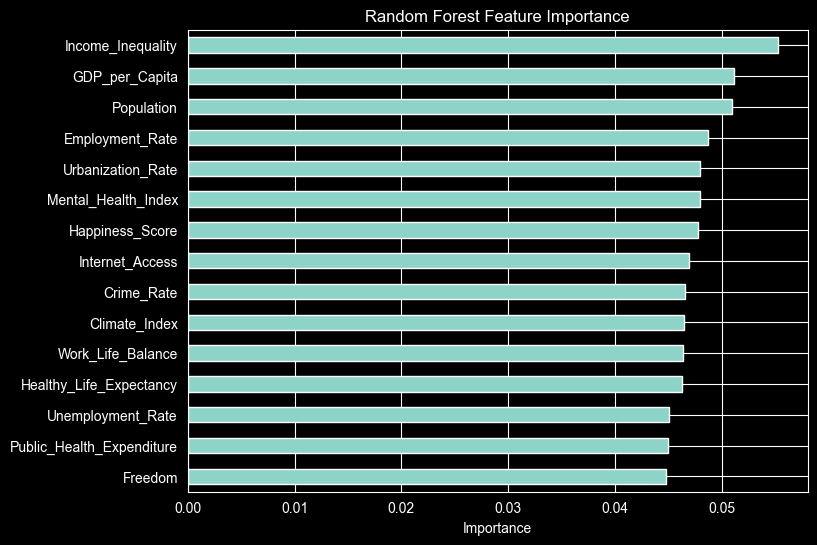

In [24]:
rf_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [25]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Regressor Results
MAE: 1.2337021523475646
RMSE: 1.4602407949659657
R2: -0.06695027660997965


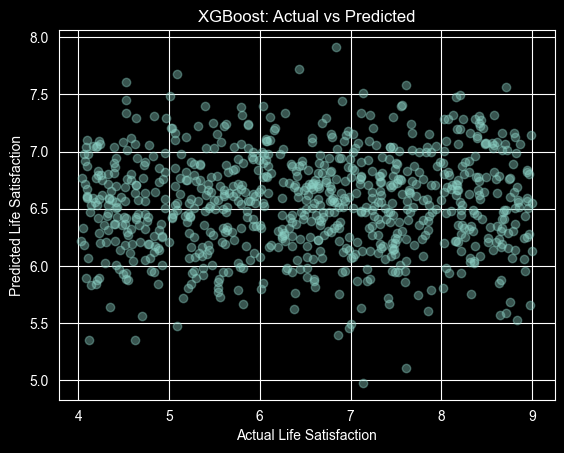

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb, alpha=0.4)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [28]:
import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(xgb_importance.head(15))

Employment_Rate              0.050682
Urbanization_Rate            0.050112
Population                   0.049122
Internet_Access              0.049011
Political_Stability          0.049001
Education_Index              0.048738
Crime_Rate                   0.048492
Mental_Health_Index          0.047628
Public_Health_Expenditure    0.046840
Freedom                      0.046323
Public_Trust                 0.045801
Climate_Index                0.045742
Income_Inequality            0.045692
Corruption_Perception        0.045352
Work_Life_Balance            0.044707
dtype: float32


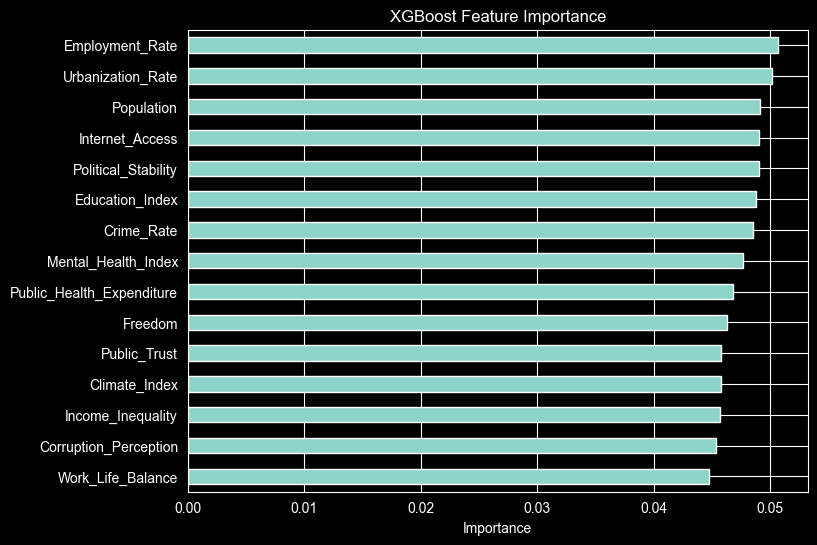

In [29]:
xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()